# Análise Exploratória — Fases 1 e 2

**Projeto:** predição de `Listening_Time_minutes` (tempo de escuta de episódios de podcast)
**Variável alvo:** `Listening_Time_minutes` (contínua → problema de **regressão**)
**Dados:** `train.csv` (750.000 linhas × 12 colunas) e `test.csv` (250.000 × 11)

Este notebook consolida as duas primeiras fases do `Diagrama_de_desenvolvimento.pdf`:

| Fase | Bloco | Onde está aqui |
|---|---|---|
| 1 | Carregamento de dados | seção 1 |
| 2 | Descrição das variáveis | seção 2.1 |
| 2 | Distribuição da variável alvo | seção 2.2 |
| 2 | Análise de variáveis numéricas | seção 2.3 |
| 2 | Análise de variáveis categóricas | seção 2.4 |
| 2 | Matriz de correlação | seção 2.5 |
| 2 | ~~Engenharia de features~~ | **fora de escopo** (decisão do projeto) |

## O que este notebook faz e o que não faz

**Faz:** descreve os dados como eles chegaram e produz uma lista priorizada de decisões
para a Fase 3 (pré-processamento).

**Não faz:** nenhuma célula altera `train` ou `test`. Não há imputação, remoção de
outliers, encoding nem criação de variáveis novas. Tudo isso é Fase 3 em diante —
o objetivo aqui é **decidir com evidência** o que fazer lá, não fazer.

## Resumo dos achados

Se você só tem dois minutos, são estes os cinco pontos:

1. **Uma única variável explica quase todo o alvo.** `Episode_Length_minutes` tem
   correlação de Pearson **0,92** com o alvo. Todo o resto é fraco.
2. **As variáveis categóricas praticamente não explicam nada.** O maior `eta²` é
   0,0058 — menos de 0,6% da variância do alvo.
3. **A regra IQR é inócua neste dataset.** Ela encontra 1 outlier em 662.907 valores
   de `Episode_Length_minutes`. As distribuições são quase uniformes.
4. **Os erros reais são violações de domínio, não outliers estatísticos:** percentuais
   acima de 100, `Number_of_Ads` chegando a 103, e 2.568 linhas onde o tempo de escuta
   excede a duração do episódio — das quais apenas **85 são erros de verdade** e o
   restante é arredondamento (a análise está na seção 2.6).
5. **O `test.csv` é mais sujo que o `train.csv`:** contém `Episode_Length_minutes` de
   **78.486.264** e `Number_of_Ads` de **2.063**, muito além de qualquer valor do treino.

Cada um desses pontos é demonstrado com dados e gráficos nas seções a seguir.

---
## 0. Configuração do ambiente

O notebook reaproveita o módulo `Pipeline/eda`, onde ficam os utilitários
estatísticos (IQR, eta², PSI) e a paleta de cores. A paleta foi escolhida para
ser legível também por quem tem daltonismo, e é aplicada em ordem fixa.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Sobe na árvore até achar a raiz do projeto (funciona rodando o notebook
# tanto da raiz quanto de dentro de Pipeline/).
RAIZ = Path.cwd()
while not (RAIZ / "train.csv").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from Pipeline.eda import EDAConfig, classificar_colunas
from Pipeline.eda.estilo import (
    DIVERGENTE, EIXO, SERIE_1, SERIE_2, SERIE_3, STATUS,
    TINTA_SECUNDARIA, TINTA_SUAVE, aplicar_estilo,
)
from Pipeline.eda.fase2_eda import consolidar_alertas, descrever_variaveis
from Pipeline.eda.utils import (
    amostrar, contar_outliers_iqr, eta_quadrado, grade_de_paineis,
    limites_iqr, psi,
)

aplicar_estilo()

# Precisa vir DEPOIS de aplicar_estilo(): o módulo força o backend "Agg"
# (para uso em script) e a mágica abaixo devolve a renderização inline.
%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Raiz do projeto:", RAIZ)

Raiz do projeto: d:\Code\Disputa_gecida


### Parâmetros da análise

Tudo o que é específico deste dataset está concentrado no objeto `cfg`. Trocar o
alvo, o identificador ou os limiares aqui é suficiente para rodar a mesma análise
sobre outro conjunto de dados.

In [2]:
cfg = EDAConfig(
    target="Listening_Time_minutes",
    id_col="id",
    outdir=RAIZ / "outputs" / "eda_notebook",
    # Regras de domínio: condições que NÃO deveriam existir nos dados.
    regras_logicas=[
        "Listening_Time_minutes > Episode_Length_minutes",
        "Number_of_Ads > 10",
        "Episode_Length_minutes <= 0",
    ],
)

print("Alvo:", cfg.target)
print("Identificador:", cfg.id_col)
print("Limite de descarte por ausentes:", f"{cfg.limite_nan_coluna}%")
print("Limite de redundância entre preditoras:", f"|r| >= {cfg.limite_correlacao_alta}")

Alvo: Listening_Time_minutes
Identificador: id
Limite de descarte por ausentes: 50.0%
Limite de redundância entre preditoras: |r| >= 0.9


---
# Fase 1 — Carregamento de Dados

Objetivo: ler os arquivos e responder a perguntas de integridade **antes** de
qualquer análise. Se algo estiver errado aqui (alvo vazando para o test, ids
duplicados, colunas desalinhadas), toda a análise seguinte fica comprometida.

## 1.1 Leitura dos arquivos

In [3]:
train = pd.read_csv(RAIZ / "train.csv")
test = pd.read_csv(RAIZ / "test.csv")

print(f"train: {train.shape[0]:,} linhas × {train.shape[1]} colunas".replace(",", "."))
print(f"test:  {test.shape[0]:,} linhas × {test.shape[1]} colunas".replace(",", "."))

train.head()

train: 750.000 linhas × 12 colunas
test:  250.000 linhas × 11 colunas


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.8100,Thursday,Night,NaN,0.0000,Positive,31.4200
1,1,Joke Junction,Episode 26,119.8000,Comedy,66.9500,Saturday,Afternoon,75.9500,2.0000,Negative,88.0124
2,2,Study Sessions,Episode 16,73.9000,Education,69.9700,Tuesday,Evening,8.9700,0.0000,Negative,44.9253
3,3,Digital Digest,Episode 45,67.1700,Technology,57.2200,Monday,Morning,78.7000,2.0000,Positive,46.2782
4,4,Mind & Body,Episode 86,110.5100,Health,80.0700,Monday,Afternoon,58.6800,3.0000,Neutral,75.6103


## 1.2 Dimensões, tipos e memória

Uma visão de alto nível: quanto de dado temos, quanto ocupa em memória e qual a
proporção de células vazias.

In [4]:
def resumo_dataset(nome, df):
    return {
        "dataset": nome,
        "linhas": len(df),
        "colunas": df.shape[1],
        "memoria_MB": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "col_numericas": df.select_dtypes(include="number").shape[1],
        "col_texto": df.select_dtypes(include=["object", "category"]).shape[1],
        "celulas_nan_pct": round(100 * df.isna().to_numpy().mean(), 3),
        "linhas_com_nan_pct": round(100 * df.isna().any(axis=1).mean(), 3),
    }

resumo = pd.DataFrame([resumo_dataset("train", train), resumo_dataset("test", test)])
resumo

,dataset,linhas,colunas,memoria_MB,col_numericas,col_texto,celulas_nan_pct,linhas_com_nan_pct
0,train,750000,12,281.6900,6,6,2.5900,28.1270
1,test,250000,11,91.9900,5,6,2.8210,28.0660


**Leitura:** só 2,6% das *células* estão vazias, mas **28% das linhas** têm ao menos
um valor ausente. Essa diferença importa muito para a Fase 3: descartar linhas
incompletas custaria mais de um quarto dos dados. A imputação não é opcional aqui,
é obrigatória.

O `test` tem uma coluna a menos — o alvo, como esperado. Confirmamos isso na seção 1.4.

In [5]:
train.dtypes.to_frame("dtype")

,dtype
id,int64
Podcast_Name,object
Episode_Title,object
Episode_Length_minutes,float64
Genre,object
Host_Popularity_percentage,float64
Publication_Day,object
Publication_Time,object
Guest_Popularity_percentage,float64
Number_of_Ads,float64


## 1.3 Verificações de integridade

Cada linha abaixo é uma pergunta cuja resposta errada invalidaria o trabalho seguinte.

In [6]:
checagens = []

def checar(item, valor, ok, observacao=""):
    checagens.append({
        "checagem": item,
        "valor": valor,
        "status": "OK" if ok else "ATENÇÃO",
        "observacao": observacao,
    })

# O alvo existe no treino e está completo?
checar("alvo presente no train", cfg.target, cfg.target in train.columns)
n_nan_alvo = int(train[cfg.target].isna().sum())
checar("NaN no alvo", n_nan_alvo, n_nan_alvo == 0,
       "linhas sem alvo teriam de ser descartadas" if n_nan_alvo else "")

# O alvo vazou para o test? (se estivesse lá, a competição não faria sentido)
checar("alvo ausente no test", cfg.target not in test.columns, cfg.target not in test.columns)

# Os identificadores são únicos e não se repetem entre os conjuntos?
dup_id = int(train[cfg.id_col].duplicated().sum())
checar(f"{cfg.id_col} único no train", dup_id, dup_id == 0)
sobrep = len(set(train[cfg.id_col]) & set(test[cfg.id_col]))
checar("sobreposição de id train/test", sobrep, sobrep == 0)

# Há linhas inteiramente duplicadas? Elas inflariam a validação cruzada.
dup_linhas = int(train.drop(columns=[cfg.id_col]).duplicated().sum())
checar("linhas duplicadas no train (sem id)", dup_linhas, dup_linhas == 0)

pd.DataFrame(checagens)

,checagem,valor,status,observacao
0,alvo presente no train,Listening_Time_minutes,OK,
1,NaN no alvo,0,OK,
2,alvo ausente no test,True,OK,
3,id único no train,0,OK,
4,sobreposição de id train/test,0,OK,
5,linhas duplicadas no train (sem id),0,OK,


**Leitura:** todas as checagens passam. O alvo está completo, não há vazamento
para o `test`, os ids são únicos e não há linhas duplicadas. Podemos seguir.

## 1.4 Alinhamento entre train e test

As colunas precisam ser as mesmas (exceto o alvo) e com os mesmos tipos — caso
contrário o pipeline treinado não se aplica ao `test`.

In [7]:
so_train = [c for c in train.columns if c not in test.columns]
so_test = [c for c in test.columns if c not in train.columns]
comuns = [c for c in train.columns if c in test.columns]
divergentes = [c for c in comuns if train[c].dtype != test[c].dtype]

pd.DataFrame([
    {"item": "colunas comuns", "quantidade": len(comuns), "colunas": ""},
    {"item": "só no train", "quantidade": len(so_train), "colunas": ", ".join(so_train)},
    {"item": "só no test", "quantidade": len(so_test), "colunas": ", ".join(so_test)},
    {"item": "dtypes divergentes", "quantidade": len(divergentes), "colunas": ", ".join(divergentes)},
])

,item,quantidade,colunas
0,colunas comuns,11,
1,só no train,1,Listening_Time_minutes
2,só no test,0,
3,dtypes divergentes,0,


**Leitura:** alinhamento perfeito. As 11 colunas do `test` são exatamente as do
`train` menos o alvo, e nenhum tipo diverge.

## 1.5 Estabilidade das distribuições (PSI)

O modelo é treinado no `train` e aplicado no `test`. Se as distribuições forem
diferentes, o desempenho medido na validação não se traduz no `test`.

O **PSI** (*Population Stability Index*) mede essa diferença comparando a proporção
de observações em cada faixa:

$$\text{PSI} = \sum_i (p^{test}_i - p^{train}_i) \cdot \ln\!\left(\frac{p^{test}_i}{p^{train}_i}\right)$$

| PSI | Interpretação |
|---|---|
| < 0,10 | estável |
| 0,10 – 0,25 | merece atenção |
| > 0,25 | deslocamento forte |

In [8]:
linhas_psi = []
for c in comuns:
    if c in (cfg.id_col, cfg.target):
        continue
    valor = psi(train[c], test[c])
    numerica = pd.api.types.is_numeric_dtype(train[c])
    linhas_psi.append({
        "coluna": c,
        "nan_pct_train": round(100 * train[c].isna().mean(), 3),
        "nan_pct_test": round(100 * test[c].isna().mean(), 3),
        "psi": round(valor, 5),
        "diagnostico": "estável" if valor < 0.10 else ("atenção" if valor < 0.25 else "deslocamento forte"),
        "max_train": float(train[c].max()) if numerica else np.nan,
        "max_test": float(test[c].max()) if numerica else np.nan,
    })

estabilidade = pd.DataFrame(linhas_psi).sort_values("psi", ascending=False)
estabilidade

,coluna,nan_pct_train,nan_pct_test,psi,diagnostico,max_train,max_test
1,Episode_Title,0.0000,0.0000,0.0006,estável,NaN,NaN
0,Podcast_Name,0.0000,0.0000,0.0002,estável,NaN,NaN
7,Guest_Popularity_percentage,19.4710,19.5330,0.0001,estável,119.9100,116.8200
2,Episode_Length_minutes,11.6120,11.4940,0.0001,estável,325.2400,"78,486,264.0000"
4,Host_Popularity_percentage,0.0000,0.0000,0.0001,estável,119.4600,117.7600
3,Genre,0.0000,0.0000,0.0001,estável,NaN,NaN
5,Publication_Day,0.0000,0.0000,0.0000,estável,NaN,NaN
6,Publication_Time,0.0000,0.0000,0.0000,estável,NaN,NaN
8,Number_of_Ads,0.0000,0.0000,0.0000,estável,103.9100,"2,063.0000"
9,Episode_Sentiment,0.0000,0.0000,0.0000,estável,NaN,NaN


## 1.6 O ponto cego do PSI

Todas as colunas aparecem como "estável" — mas repare nas colunas `max_train` e
`max_test` acima. O PSI é calculado sobre **faixas de quantis**, então um punhado
de valores absurdos cai todo dentro da última faixa e **não move o índice**.

Um teste direto revela o que o PSI não viu:

In [9]:
linhas_fora = []
for c in comuns:
    if c in (cfg.id_col, cfg.target) or not pd.api.types.is_numeric_dtype(train[c]):
        continue
    minimo, maximo = train[c].min(), train[c].max()
    fora = int(((test[c] < minimo) | (test[c] > maximo)).sum())
    if fora:
        linhas_fora.append({
            "coluna": c,
            "linhas_do_test_fora_do_intervalo": fora,
            "max_train": maximo,
            "max_test": test[c].max(),
            "razao": test[c].max() / maximo,
        })

pd.DataFrame(linhas_fora)

,coluna,linhas_do_test_fora_do_intervalo,max_train,max_test,razao
0,Episode_Length_minutes,2,325.2400,"78,486,264.0000","241,317.9929"
1,Number_of_Ads,1,103.9100,"2,063.0000",19.8537


In [10]:
# As linhas responsáveis, no test:
test.nlargest(3, "Episode_Length_minutes")[
    ["id", "Episode_Length_minutes", "Number_of_Ads", "Genre"]
]

,id,Episode_Length_minutes,Number_of_Ads,Genre
56597,806597,"78,486,264.0000",0.0000,Business
54434,804434,"7,575.0000",2.0000,News
180050,930050,120.7300,0.0000,Technology


**Achado importante.** O `test` contém um episódio de **78.486.264 minutos** —
cerca de 149 anos — e outro de 7.575 minutos, contra um máximo de 325 no treino.
Há ainda um `Number_of_Ads` de **2.063**.

Consequência prática para a Fase 3: qualquer `StandardScaler` ou `MinMaxScaler`
ajustado no `train` vai produzir valores absurdos para essas linhas, e um
`MinMaxScaler` ajustado no conjunto completo esmagaria todo o resto dos dados
num intervalo minúsculo. Essas linhas precisam ser tratadas **antes** do
escalonamento.

### Comparação visual das distribuições

Para o gráfico ficar legível, os eixos são limitados à janela entre os percentis
0,1 e 99,9 — os valores extremos identificados acima ficariam fora de escala e
achatariam todo o resto. O título de cada painel informa quantos pontos ficaram
fora da janela.

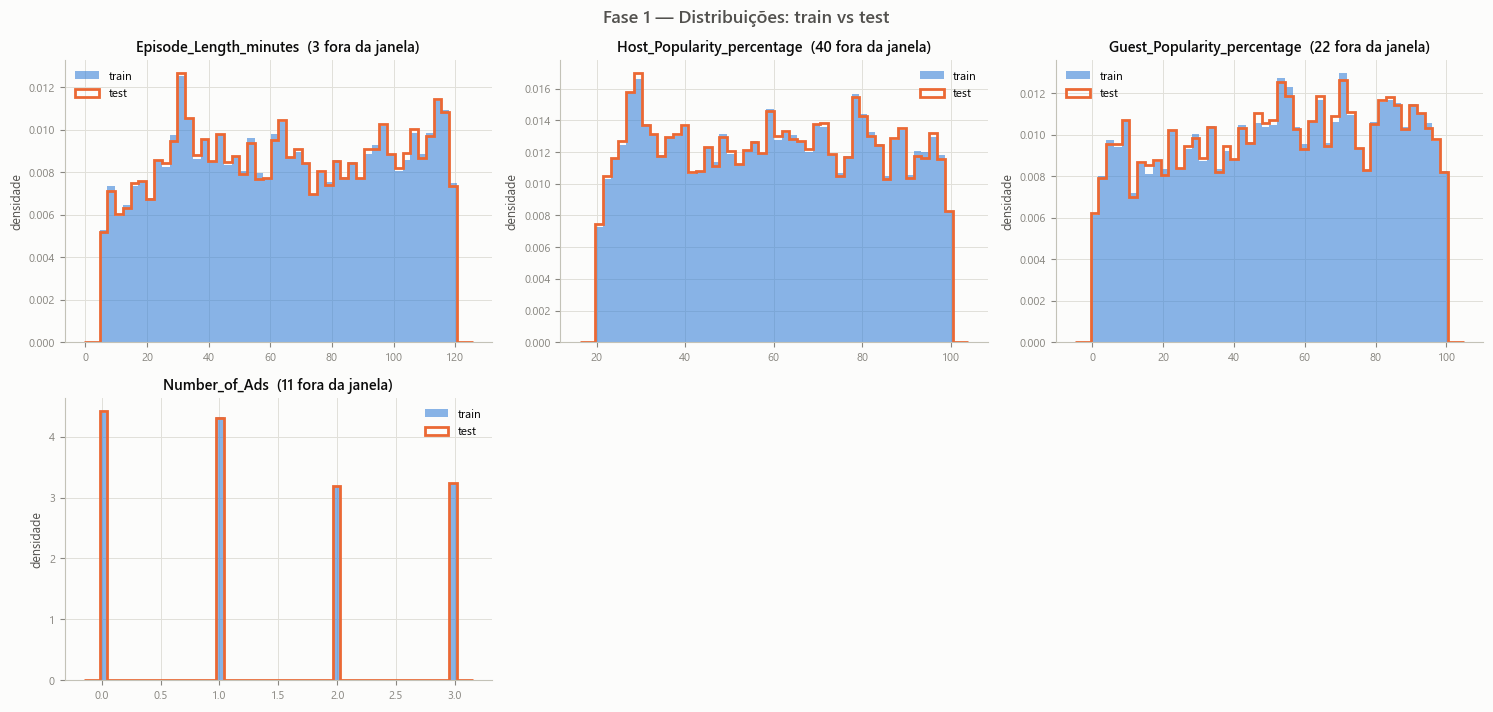

In [11]:
numericas_comuns = [
    c for c in comuns
    if c not in (cfg.id_col, cfg.target) and pd.api.types.is_numeric_dtype(train[c])
]

fig, axes = grade_de_paineis(len(numericas_comuns), cfg)
for ax, c in zip(axes, numericas_comuns):
    st, se = train[c].dropna(), test[c].dropna()
    juntas = pd.concat([st, se])
    inf, sup = juntas.quantile(0.001), juntas.quantile(0.999)
    margem = (sup - inf) * 0.05 or 1.0
    inf, sup = inf - margem, sup + margem
    n_fora = int(((juntas < inf) | (juntas > sup)).sum())

    faixas = np.linspace(inf, sup, 51)
    ax.hist(st.clip(inf, sup), bins=faixas, density=True, color=SERIE_1,
            alpha=0.55, label="train", edgecolor="none")
    ax.hist(se.clip(inf, sup), bins=faixas, density=True, histtype="step",
            color=SERIE_2, linewidth=2.0, label="test")
    ax.set_title(f"{c}" + (f"  ({n_fora} fora da janela)" if n_fora else ""))
    ax.set_ylabel("densidade")
    ax.legend()

fig.suptitle("Fase 1 — Distribuições: train vs test", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Leitura:** dentro da janela robusta as duas curvas praticamente se sobrepõem —
o `test` é uma amostra da mesma população. O problema não é deslocamento de
distribuição, é um punhado de registros corrompidos.

Repare também no formato: `Episode_Length_minutes`, `Host_Popularity_percentage` e
`Guest_Popularity_percentage` são **quase uniformes**, não normais. Isso já
antecipa por que a regra IQR não vai encontrar outliers (seção 2.3).

---
# Fase 2 — Análise Exploratória (EDA)

A partir daqui trabalhamos **apenas com o `train`**, que é o único conjunto com o
alvo. O `test` só volta na Fase 5.

## 2.1 Descrição das variáveis

Primeiro classificamos cada coluna pelo seu papel. A classificação é **estrutural**
(tipo do dado + cardinalidade), sem conhecimento de domínio:

- **constante** — um único valor distinto; não carrega informação
- **identificador** — quase todos os valores distintos (> 95%)
- **numérica** — tipo numérico
- **alta cardinalidade** — texto com mais de 50 categorias
- **categórica** — o restante

In [12]:
colunas = classificar_colunas(train, cfg)

print("numéricas:          ", colunas.numericas)
print("categóricas:        ", colunas.categoricas)
print("alta cardinalidade: ", colunas.alta_cardinalidade)
print("identificadores:    ", colunas.identificadores)
print("constantes:         ", colunas.constantes)

numéricas:           ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']
categóricas:         ['Podcast_Name', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']
alta cardinalidade:  ['Episode_Title']
identificadores:     []
constantes:          []


In [13]:
descricao = descrever_variaveis(train, cfg, colunas)
descricao

,coluna,papel,dtype,n_preenchidos,n_nan,nan_pct,nunique,unicidade_pct,valor_dominante,dominante_pct,memoria_MB
0,id,id,int64,750000,0,0.0000,750000,100.0000,0,0.0000,5.7220
1,Podcast_Name,categorica,object,750000,0,0.0000,48,0.0060,Tech Talks,3.0460,44.1750
2,Episode_Title,alta cardinalidade,object,750000,0,0.0000,100,0.0130,Episode 71,1.4020,42.1500
3,Episode_Length_minutes,numerica,float64,662907,87093,11.6120,12268,1.6360,6.6000,0.1230,5.7220
4,Genre,categorica,object,750000,0,0.0000,10,0.0010,Sports,11.6810,40.3420
5,Host_Popularity_percentage,numerica,float64,750000,0,0.0000,8038,1.0720,38.6800,0.0750,5.7220
6,Publication_Day,categorica,object,750000,0,0.0000,7,0.0010,Sunday,15.4590,40.1380
7,Publication_Time,categorica,object,750000,0,0.0000,4,0.0010,Night,26.2470,40.0210
8,Guest_Popularity_percentage,numerica,float64,603970,146030,19.4710,10019,1.3360,68.5300,0.0500,5.7220
9,Number_of_Ads,numerica,float64,749999,1,0.0000,12,0.0020,0.0000,29.0120,5.7220


### Valores ausentes

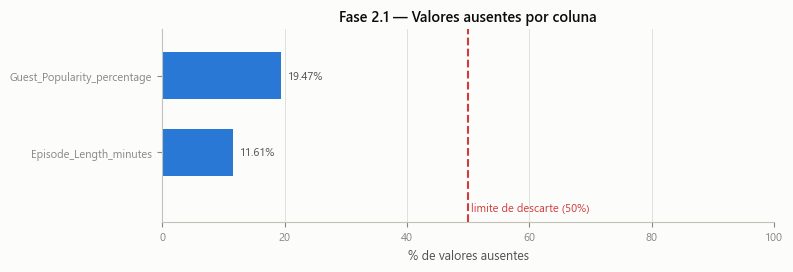

In [14]:
com_nan = descricao[descricao["nan_pct"] > 0].sort_values("nan_pct")

fig, ax = plt.subplots(figsize=(8, 2.8))
pos = np.arange(len(com_nan))
ax.barh(pos, com_nan["nan_pct"], color=SERIE_1, height=0.6)
ax.set_yticks(pos, com_nan["coluna"])
ax.set_xlabel("% de valores ausentes")
ax.set_title("Fase 2.1 — Valores ausentes por coluna")
ax.axvline(cfg.limite_nan_coluna, color=STATUS["critico"], linewidth=1.5, linestyle="--")
ax.set_ylim(-0.9, len(com_nan) - 0.4)
ax.text(cfg.limite_nan_coluna, -0.8, f" limite de descarte ({cfg.limite_nan_coluna:.0f}%)",
        color=STATUS["critico"], fontsize=8, va="bottom")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
for y, v in zip(pos, com_nan["nan_pct"]):
    ax.text(v + 1, y, f"{v:.2f}%", va="center", fontsize=8, color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Leitura:**

- `Guest_Popularity_percentage` — 19,47% ausentes (146.030 linhas)
- `Episode_Length_minutes` — 11,61% ausentes (87.093 linhas)
- `Number_of_Ads` — **1** linha ausente (0,0001%)

Nenhuma coluna chega perto do limite de 50% que justificaria descarte. Todas serão
imputadas na Fase 3.

Dois detalhes que mudam a estratégia:

1. **A ausência está na variável mais importante.** Como veremos na seção 2.3,
   `Episode_Length_minutes` sozinha explica quase todo o alvo. Imputar 11,6% dela
   com a mediana degradaria justamente o sinal mais forte que temos — vale testar
   imputação por modelo (KNN, ou uma regressão a partir das outras colunas).
2. **Um único NaN em `Number_of_Ads` arredonda para 0,00%.** É por isso que
   sinalizamos ausentes pela **contagem absoluta**, não pelo percentual: em 750 mil
   linhas, um punhado de valores problemáticos desaparece no arredondamento.

## 2.2 Distribuição da variável alvo

`Listening_Time_minutes` é contínua — o problema é de **regressão**. A forma da sua
distribuição determina qual métrica faz sentido e se alguma transformação é útil.

In [15]:
alvo = train[cfg.target].dropna()
n_out_alvo, pct_out_alvo = contar_outliers_iqr(alvo)
amostra_alvo = alvo.sample(n=5000, random_state=cfg.random_state)
_, p_normal = stats.normaltest(amostra_alvo)

pd.DataFrame([
    {"metrica": "n", "valor": len(alvo)},
    {"metrica": "média", "valor": alvo.mean()},
    {"metrica": "mediana", "valor": alvo.median()},
    {"metrica": "desvio padrão", "valor": alvo.std()},
    {"metrica": "mínimo", "valor": alvo.min()},
    {"metrica": "p25", "valor": alvo.quantile(0.25)},
    {"metrica": "p75", "valor": alvo.quantile(0.75)},
    {"metrica": "p99", "valor": alvo.quantile(0.99)},
    {"metrica": "máximo", "valor": alvo.max()},
    {"metrica": "skewness (assimetria)", "valor": alvo.skew()},
    {"metrica": "kurtosis (excesso)", "valor": alvo.kurt()},
    {"metrica": "% de zeros", "valor": 100 * (alvo == 0).mean()},
    {"metrica": "% negativos", "valor": 100 * (alvo < 0).mean()},
    {"metrica": "outliers IQR", "valor": n_out_alvo},
    {"metrica": "p-valor normalidade (D'Agostino, n=5k)", "valor": p_normal},
])

,metrica,valor
0,n,"750,000.0000"
1,média,45.4374
2,mediana,43.3795
3,desvio padrão,27.1383
4,mínimo,0.0000
5,p25,23.1783
6,p75,64.8116
7,p99,109.3963
8,máximo,119.9700
9,skewness (assimetria),0.3508


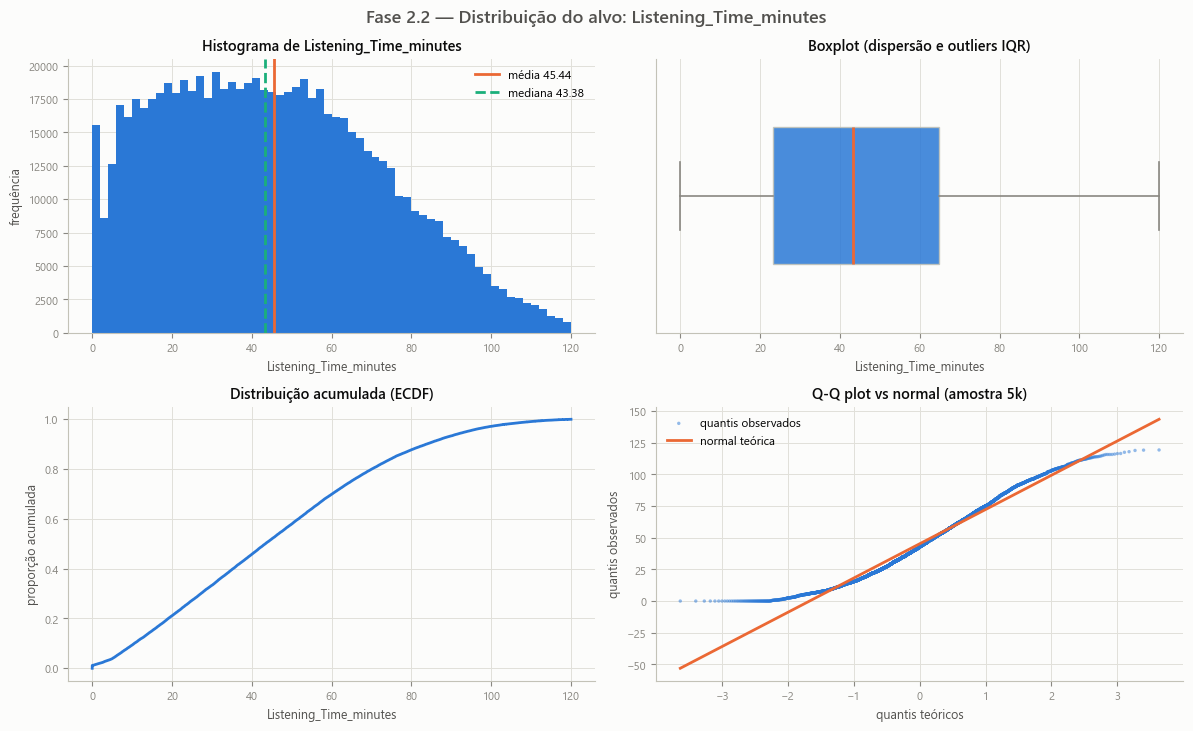

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.4))

# Histograma
ax = axes[0, 0]
ax.hist(alvo, bins=60, color=SERIE_1, edgecolor="none")
ax.axvline(alvo.mean(), color=SERIE_2, linewidth=2, label=f"média {alvo.mean():.2f}")
ax.axvline(alvo.median(), color=SERIE_3, linewidth=2, linestyle="--",
           label=f"mediana {alvo.median():.2f}")
ax.set_title(f"Histograma de {cfg.target}")
ax.set_xlabel(cfg.target); ax.set_ylabel("frequência"); ax.legend()

# Boxplot
ax = axes[0, 1]
cx = ax.boxplot(alvo, vert=False, widths=0.5, patch_artist=True,
                flierprops={"marker": ".", "markersize": 2,
                            "markerfacecolor": TINTA_SUAVE,
                            "markeredgecolor": "none", "alpha": 0.3})
cx["boxes"][0].set(facecolor=SERIE_1, edgecolor=EIXO, alpha=0.85)
for el in ("whiskers", "caps"):
    for a in cx[el]:
        a.set(color=TINTA_SUAVE, linewidth=1.2)
cx["medians"][0].set(color=SERIE_2, linewidth=2)
ax.set_title("Boxplot (dispersão e outliers IQR)")
ax.set_xlabel(cfg.target); ax.set_yticks([]); ax.grid(axis="y", visible=False)

# ECDF
ax = axes[1, 0]
ordenado = np.sort(alvo.to_numpy())
ax.plot(ordenado, np.arange(1, len(ordenado) + 1) / len(ordenado), color=SERIE_1)
ax.set_title("Distribuição acumulada (ECDF)")
ax.set_xlabel(cfg.target); ax.set_ylabel("proporção acumulada")

# Q-Q plot
ax = axes[1, 1]
(osm, osr), (incl, interc, _) = stats.probplot(amostra_alvo, dist="norm")
ax.scatter(osm, osr, s=6, color=SERIE_1, alpha=0.5, edgecolors="none",
           label="quantis observados")
ax.plot(osm, incl * osm + interc, color=SERIE_2, label="normal teórica")
ax.set_title("Q-Q plot vs normal (amostra 5k)")
ax.set_xlabel("quantis teóricos"); ax.set_ylabel("quantis observados"); ax.legend()

fig.suptitle(f"Fase 2.2 — Distribuição do alvo: {cfg.target}", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()



**Leitura:**

- **Assimetria leve** (skewness 0,35) e **caudas curtas** (kurtosis −0,66, ou seja,
  achatada em relação à normal). O alvo **não** é fortemente enviesado à direita,
  que é o caso típico em que se aplicaria `log1p`. Aqui essa transformação não é
  necessária e provavelmente atrapalharia.
- **Zero outliers pela regra IQR.** A distribuição é larga e sem caudas longas.
- **O Q-Q plot mostra o desvio da normal nas duas pontas**, com um "piso" achatado
  perto de zero: 1,14% das observações são exatamente **0**. São ouvintes que
  abriram o episódio e não escutaram nada — um comportamento qualitativamente
  diferente do resto, que vale investigar antes de modelar.
- O teste de normalidade rejeita a hipótese nula (p ≈ 6e−74), mas com 750 mil
  observações qualquer desvio mínimo seria rejeitado. **A forma do gráfico informa
  mais do que o p-valor.**
- O alvo está limitado a **[0; 120]**. Nada impede um modelo de regressão de prever
  valores negativos ou acima de 120 — vale recortar as previsões nesse intervalo
  na Fase 5.

**Implicação para as métricas (Fase 4):** distribuição sem cauda longa e sem
transformação necessária → **RMSE** é uma escolha adequada como métrica principal.
O RMSLE previsto no diagrama faz menos sentido aqui (ele penaliza erro relativo,
útil quando o alvo cobre várias ordens de grandeza — não é o caso).

## 2.3 Análise das variáveis numéricas

Para cada numérica: distribuição, contagem de outliers pela regra IQR e relação
com o alvo.

In [17]:
linhas_num = []
for c in colunas.numericas:
    serie = train[c].dropna()
    inf, sup = limites_iqr(serie)
    n_out, pct_out = contar_outliers_iqr(serie)
    linhas_num.append({
        "coluna": c,
        "n": len(serie),
        "nan_pct": round(100 * train[c].isna().mean(), 3),
        "media": serie.mean(),
        "mediana": serie.median(),
        "desvio": serie.std(),
        "min": serie.min(),
        "max": serie.max(),
        "skew": serie.skew(),
        "kurtosis": serie.kurt(),
        "iqr_inf": inf,
        "iqr_sup": sup,
        "outliers_iqr": n_out,
        "outliers_pct": round(pct_out, 4),
        "zeros_pct": round(100 * (serie == 0).mean(), 3),
        "n_valores_distintos": serie.nunique(),
    })

resumo_num = pd.DataFrame(linhas_num)
resumo_num

,coluna,n,nan_pct,media,mediana,desvio,min,max,skew,kurtosis,iqr_inf,iqr_sup,outliers_iqr,outliers_pct,zeros_pct,n_valores_distintos
0,Episode_Length_minutes,662907,11.6120,64.5047,63.8400,32.9696,0.0000,325.2400,-0.0020,-1.2030,-51.7800,181.5800,1,0.0002,0.0000,12268
1,Host_Popularity_percentage,750000,0.0000,59.8599,60.0500,22.8731,1.3000,119.4600,0.0049,-1.2067,-20.7700,139.7100,0,0.0000,0.0000,8038
2,Guest_Popularity_percentage,603970,19.4710,52.2364,53.5800,28.4512,0.0000,119.9100,-0.1070,-1.1501,-43.9500,148.9300,0,0.0000,0.0000,10019
3,Number_of_Ads,749999,0.0000,1.3489,1.0000,1.1511,0.0000,103.9100,6.0330,505.8939,-3.0000,5.0000,9,0.0012,29.0120,12


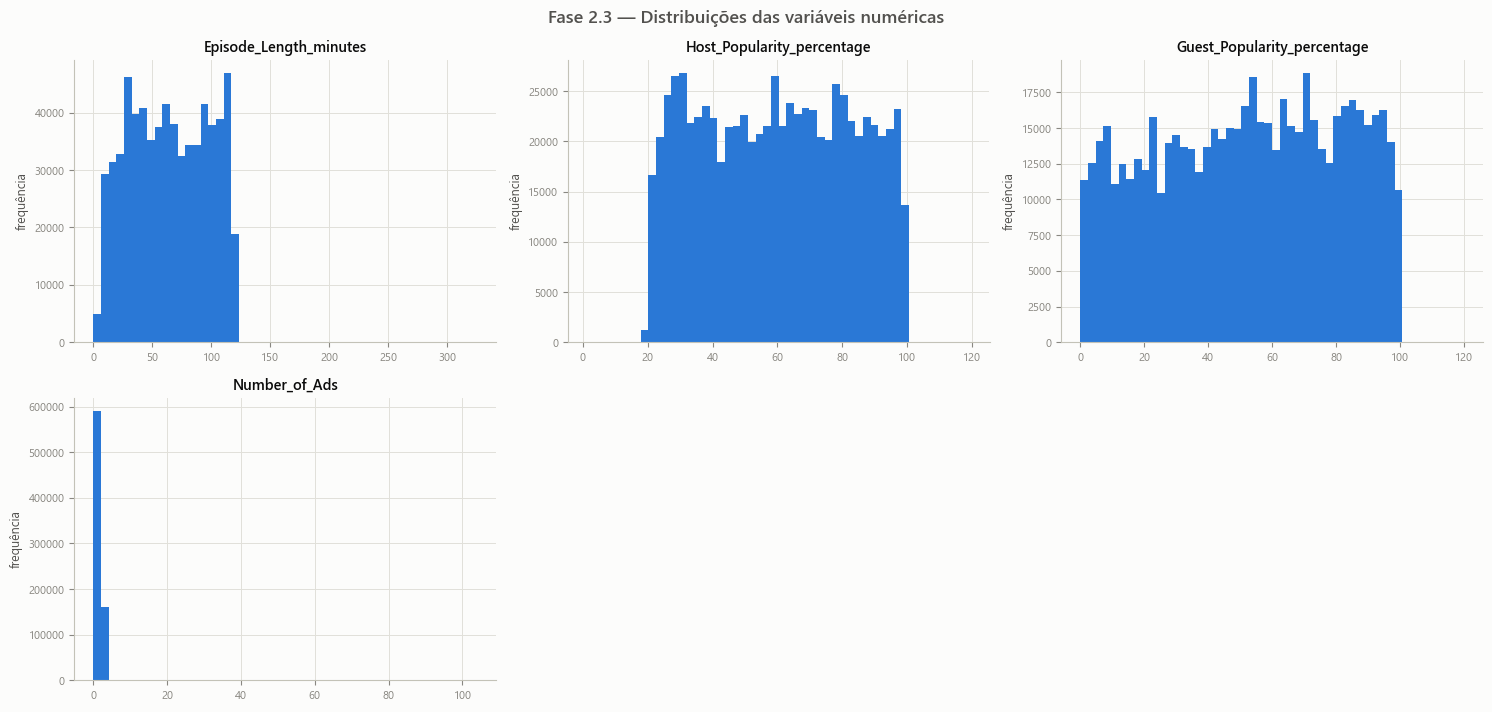

In [18]:
fig, axes = grade_de_paineis(len(colunas.numericas), cfg)
for ax, c in zip(axes, colunas.numericas):
    ax.hist(train[c].dropna(), bins=50, color=SERIE_1, edgecolor="none")
    ax.set_title(c)
    ax.set_ylabel("frequência")
fig.suptitle("Fase 2.3 — Distribuições das variáveis numéricas", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

### Outliers pela regra IQR

A regra de Tukey marca como outlier tudo que estiver fora de
$[Q_1 - 1{,}5 \cdot IQR;\ Q_3 + 1{,}5 \cdot IQR]$.

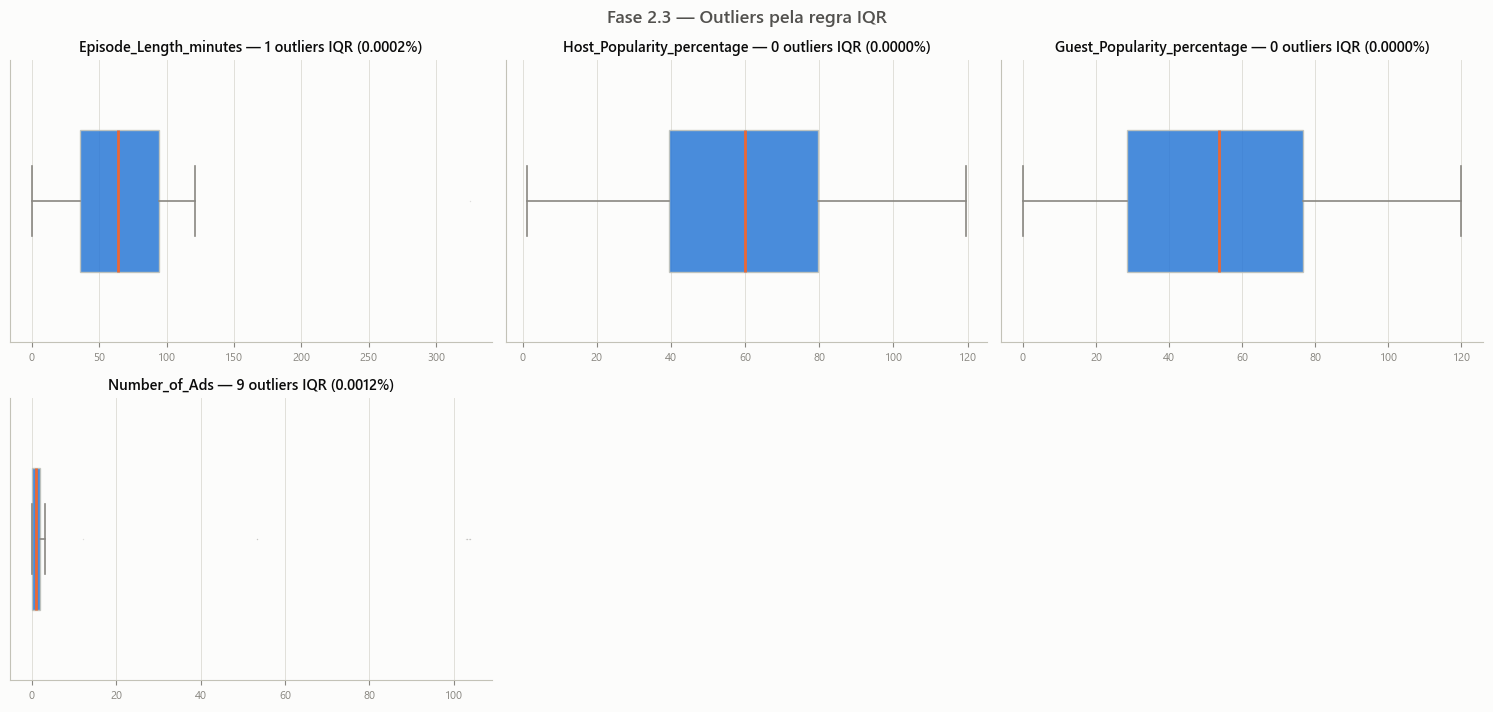

In [19]:
fig, axes = grade_de_paineis(len(colunas.numericas), cfg)
for ax, c in zip(axes, colunas.numericas):
    serie = train[c].dropna()
    cx = ax.boxplot(serie, vert=False, widths=0.5, patch_artist=True,
                    flierprops={"marker": ".", "markersize": 2,
                                "markerfacecolor": TINTA_SUAVE,
                                "markeredgecolor": "none", "alpha": 0.25})
    cx["boxes"][0].set(facecolor=SERIE_1, edgecolor=EIXO, alpha=0.85)
    for el in ("whiskers", "caps"):
        for a in cx[el]:
            a.set(color=TINTA_SUAVE, linewidth=1.2)
    cx["medians"][0].set(color=SERIE_2, linewidth=2)
    n_out, pct_out = contar_outliers_iqr(serie)
    ax.set_title(f"{c} — {n_out} outliers IQR ({pct_out:.4f}%)")
    ax.set_yticks([]); ax.grid(axis="y", visible=False)
fig.suptitle("Fase 2.3 — Outliers pela regra IQR", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Achado importante — a regra IQR é praticamente inócua neste dataset.**

| coluna | limite superior IQR | máximo observado | outliers |
|---|---|---|---|
| `Episode_Length_minutes` | 181,6 | 325,2 | **1** em 662.907 |
| `Host_Popularity_percentage` | 139,7 | 119,5 | **0** |
| `Guest_Popularity_percentage` | 148,9 | 119,9 | **0** |
| `Number_of_Ads` | 5,0 | 103,9 | **9** |

O motivo está nos histogramas acima: as três primeiras variáveis são **quase
uniformes** (kurtosis ≈ −1,2). Uma distribuição uniforme tem quartis muito
afastados, o que empurra os limites do IQR para longe — no caso de
`Host_Popularity_percentage`, para 139,7, um valor que a variável nunca alcança.

Isso tem uma consequência direta no plano do diagrama, que prevê "IQR clipping ·
winsorization · z-score > 3" na Fase 3: **esse tratamento não removeria os erros
reais dos dados**. Percentuais de 119% passariam intactos, porque estatisticamente
eles não são extremos — são apenas impossíveis.

Os erros de verdade são pegos por **regras de domínio** (seção 2.6), não por
estatística descritiva.

`Number_of_Ads` é o caso oposto e igualmente instrutivo: skewness de **6,03** e
kurtosis de **506** produzidas por apenas 9 valores corrompidos (até 103,91) numa
variável cuja escala real é 0 a 3. Um punhado de erros distorce completamente as
estatísticas de forma.

### Relação de cada numérica com o alvo

A dispersão usa uma amostra de 20 mil linhas (750 mil pontos empastariam o
gráfico). A linha laranja é a **média do alvo por decil** da variável, calculada
sobre a base completa — ela revela a forma da relação, inclusive se for não linear.

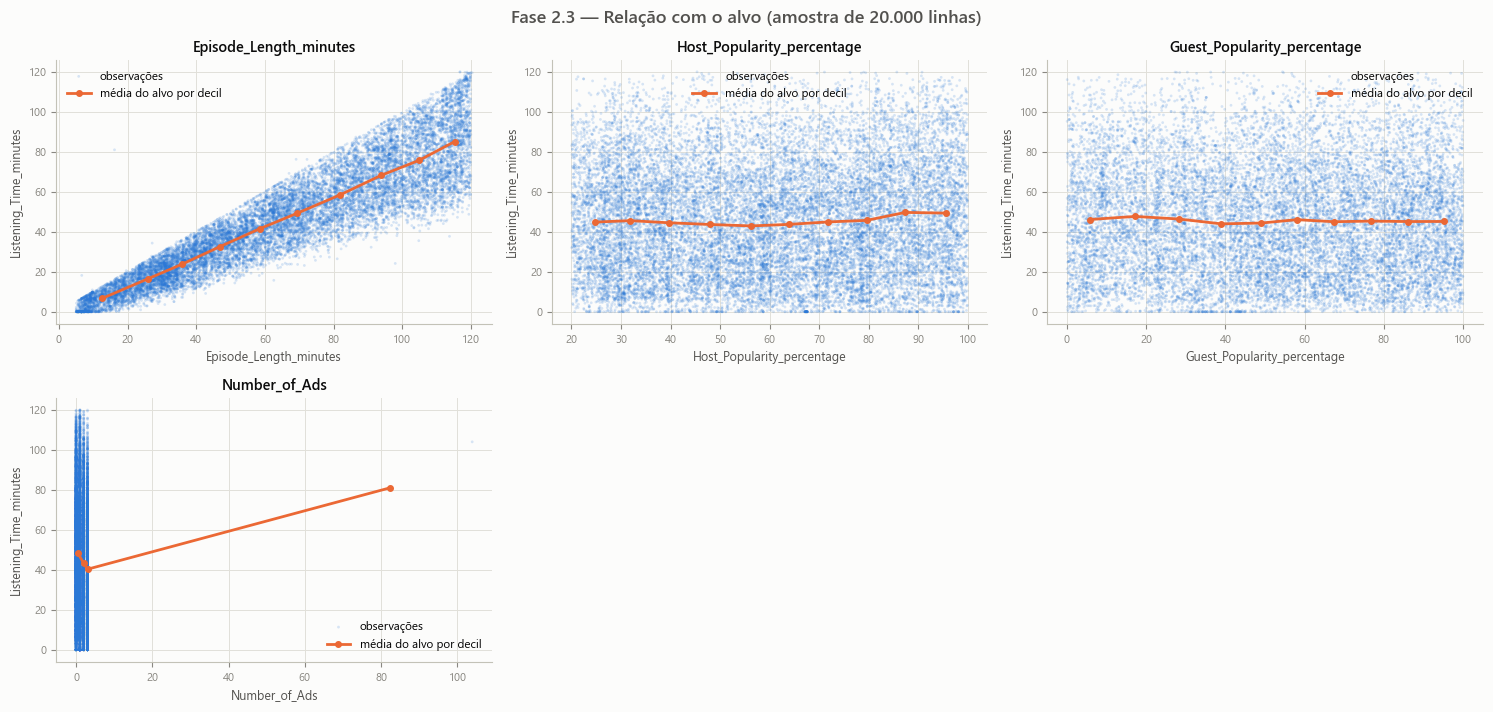

In [20]:
amostra = amostrar(train[colunas.numericas + [cfg.target]], cfg.amostra_scatter, cfg.random_state)

fig, axes = grade_de_paineis(len(colunas.numericas), cfg)
for ax, c in zip(axes, colunas.numericas):
    par = amostra[[c, cfg.target]].dropna()
    ax.scatter(par[c], par[cfg.target], s=4, alpha=0.18, color=SERIE_1,
               edgecolors="none", label="observações")
    completo = train[[c, cfg.target]].dropna()
    faixas = pd.qcut(completo[c], q=10, duplicates="drop")
    perfil = completo.groupby(faixas, observed=True).agg(x=(c, "mean"), y=(cfg.target, "mean"))
    ax.plot(perfil["x"], perfil["y"], color=SERIE_2, marker="o", markersize=4,
            label="média do alvo por decil")
    ax.set_title(c); ax.set_xlabel(c); ax.set_ylabel(cfg.target); ax.legend()

fig.suptitle("Fase 2.3 — Relação com o alvo (amostra de 20.000 linhas)", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

In [21]:
linhas_corr = []
for c in colunas.numericas:
    par = train[[c, cfg.target]].dropna()
    linhas_corr.append({
        "coluna": c,
        "pearson": par[c].corr(par[cfg.target]),
        "spearman": par[c].corr(par[cfg.target], method="spearman"),
        "n_pares": len(par),
    })

corr_alvo = (pd.DataFrame(linhas_corr)
             .assign(abs_pearson=lambda d: d["pearson"].abs())
             .sort_values("abs_pearson", ascending=False)
             .drop(columns="abs_pearson"))
corr_alvo

,coluna,pearson,spearman,n_pares
0,Episode_Length_minutes,0.9167,0.9317,662907
3,Number_of_Ads,-0.1183,-0.1153,749999
1,Host_Popularity_percentage,0.0509,0.0454,750000
2,Guest_Popularity_percentage,-0.0160,-0.0145,603970


**Leitura — este é o achado central do projeto:**

| variável | Pearson | Spearman |
|---|---|---|
| `Episode_Length_minutes` | **0,917** | **0,932** |
| `Number_of_Ads` | −0,118 | −0,115 |
| `Host_Popularity_percentage` | 0,051 | 0,045 |
| `Guest_Popularity_percentage` | −0,016 | −0,015 |

**`Episode_Length_minutes` sozinha explica ~84% da variância do alvo** (0,917² = 0,84).
O gráfico de dispersão mostra por quê: os pontos formam uma faixa triangular bem
definida, com o alvo limitado superiormente pela duração do episódio — faz sentido,
não se escuta mais tempo do que o episódio dura. E a média por decil é uma reta.

As demais variáveis são quase planas. `Number_of_Ads` tem o segundo sinal mais forte
e na direção esperada (mais anúncios → menos escuta), mas seu gráfico está distorcido
pelos 9 valores corrompidos, que puxam o último decil para fora da escala.

**O que isso significa para as próximas fases:**

1. O *baseline* é essencialmente uma função de `Episode_Length_minutes`. Uma
   regressão linear simples já deve chegar perto do teto do sinal linear disponível.
2. O ganho dos modelos mais complexos (Random Forest, XGBoost) virá de capturar o
   **resíduo** — a relação não linear entre duração, anúncios e a fração escutada.
3. Como Pearson ≈ Spearman em todas as variáveis, não há relação monotônica forte
   que a correlação linear esteja deixando escapar.

## 2.4 Análise das variáveis categóricas

Para medir a associação entre uma variável **categórica** e um alvo **contínuo**
usamos o **eta quadrado** (η²), que é o R² de uma ANOVA de um fator:

$$\eta^2 = \frac{\text{variância entre grupos}}{\text{variância total}}$$

Ele responde: *que fração da variância do alvo é explicada por saber a qual
categoria a observação pertence?* Vai de 0 (nenhuma) a 1 (total).

In [22]:
todas_cat = colunas.todas_categoricas
linhas_cat = []
detalhes_cat = {}

for c in todas_cat:
    agrupado = (train.groupby(c, observed=True)[cfg.target]
                .agg(n="count", media="mean", mediana="median", desvio="std")
                .reset_index())
    agrupado["freq_pct"] = round(100 * agrupado["n"] / len(train), 3)
    detalhes_cat[c] = agrupado.sort_values("media", ascending=False)

    eta2 = eta_quadrado(train, c, cfg.target)
    linhas_cat.append({
        "coluna": c,
        "n_categorias": train[c].nunique(),
        "nan_pct": round(100 * train[c].isna().mean(), 3),
        "categoria_dominante": agrupado.loc[agrupado["n"].idxmax(), c],
        "dominante_pct": agrupado["freq_pct"].max(),
        "media_alvo_min": agrupado["media"].min(),
        "media_alvo_max": agrupado["media"].max(),
        "amplitude_media_alvo": agrupado["media"].max() - agrupado["media"].min(),
        "eta2_vs_alvo": round(eta2, 5),
    })

resumo_cat = pd.DataFrame(linhas_cat).sort_values("eta2_vs_alvo", ascending=False)
resumo_cat

,coluna,n_categorias,nan_pct,categoria_dominante,dominante_pct,media_alvo_min,media_alvo_max,amplitude_media_alvo,eta2_vs_alvo
5,Episode_Title,100,0.0000,Episode 71,1.4020,40.6211,51.2217,10.6006,0.0058
0,Podcast_Name,48,0.0000,Tech Talks,3.0460,41.8003,48.1056,6.3052,0.0026
4,Episode_Sentiment,3,0.0000,Neutral,33.5050,44.0968,46.7238,2.6270,0.0016
3,Publication_Time,4,0.0000,Night,26.2470,44.7616,46.4567,1.6951,0.0006
1,Genre,10,0.0000,Sports,11.6810,44.4061,46.5784,2.1722,0.0006
2,Publication_Day,7,0.0000,Sunday,15.4590,44.8174,46.1314,1.3140,0.0003


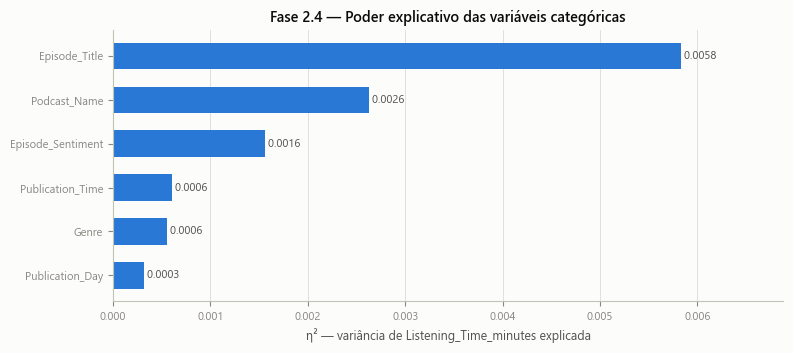

In [23]:
ordenado = resumo_cat.sort_values("eta2_vs_alvo")

fig, ax = plt.subplots(figsize=(8, 3.6))
pos = np.arange(len(ordenado))
ax.barh(pos, ordenado["eta2_vs_alvo"], color=SERIE_1, height=0.6)
ax.set_yticks(pos, ordenado["coluna"])
ax.set_xlabel(f"η² — variância de {cfg.target} explicada")
ax.set_title("Fase 2.4 — Poder explicativo das variáveis categóricas")
ax.set_xlim(0, ordenado["eta2_vs_alvo"].max() * 1.18)
ax.grid(axis="y", visible=False)
for y, v in zip(pos, ordenado["eta2_vs_alvo"]):
    ax.text(v, y, f" {v:.4f}", va="center", fontsize=8, color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Leitura:** o maior η² é **0,0058** (`Episode_Title`). Ou seja, a variável
categórica mais informativa do dataset explica **0,58%** da variância do alvo.
`Genre`, `Publication_Day` e `Publication_Time` ficam abaixo de 0,0007 — são
praticamente ruído em relação ao alvo.

Isso é coerente com a seção 2.3: quase todo o sinal está na duração do episódio.

Os gráficos abaixo detalham cada variável: à esquerda a frequência das categorias,
à direita a distribuição do alvo dentro de cada uma.

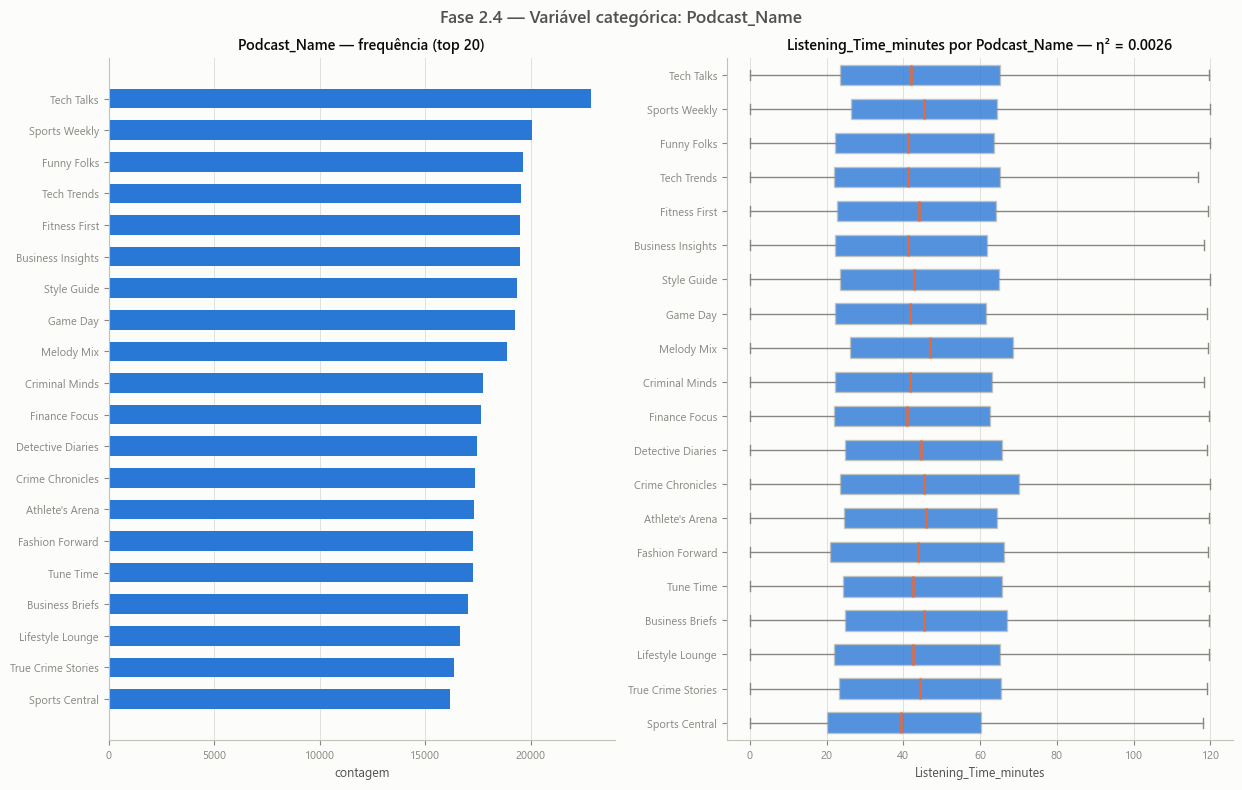

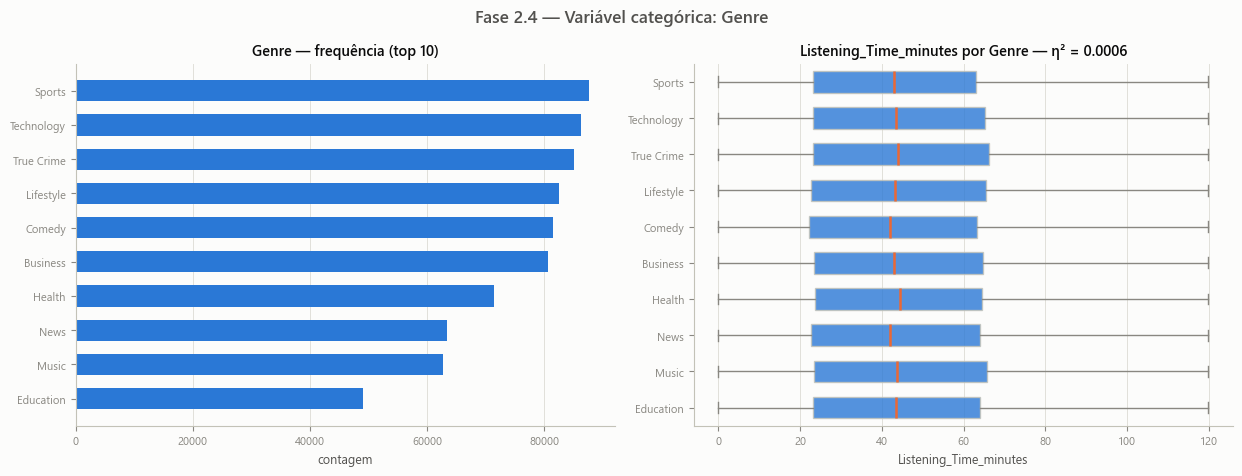

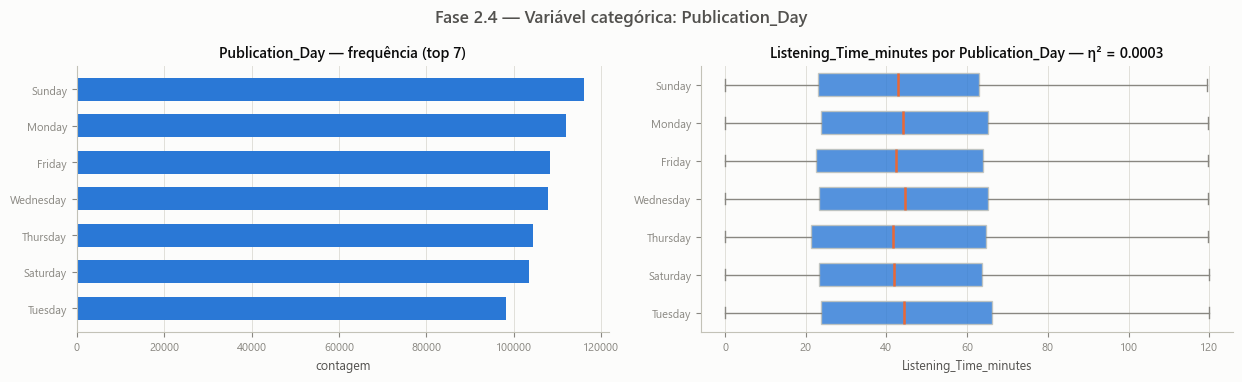

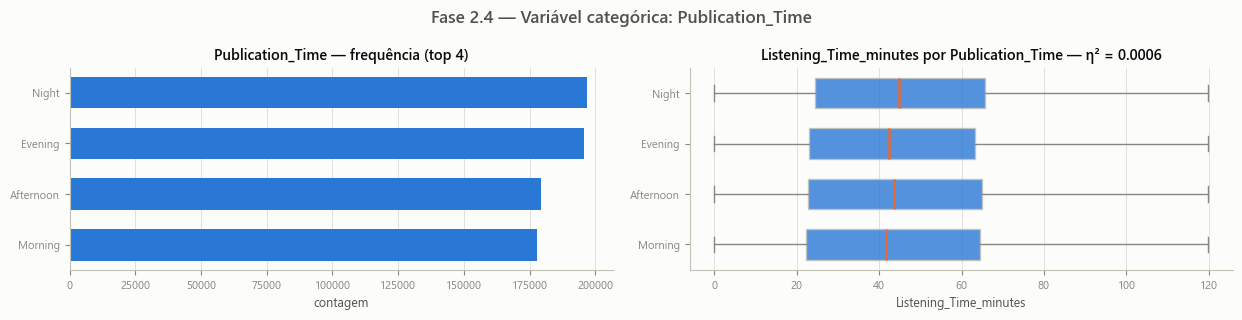

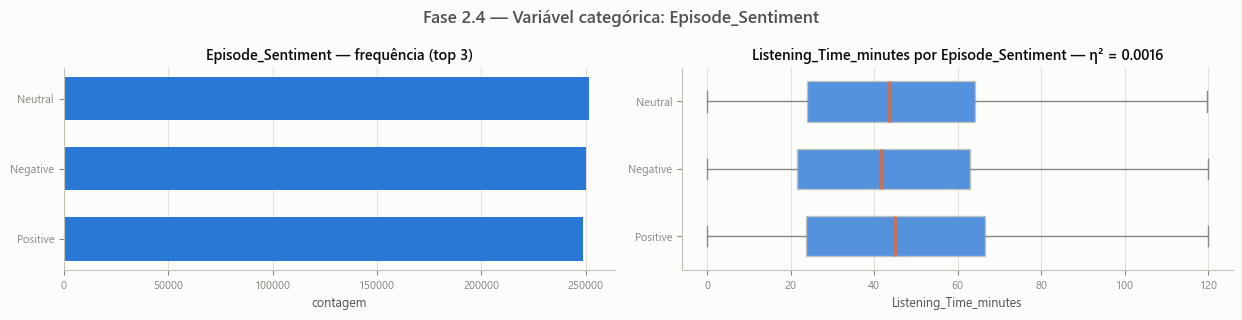

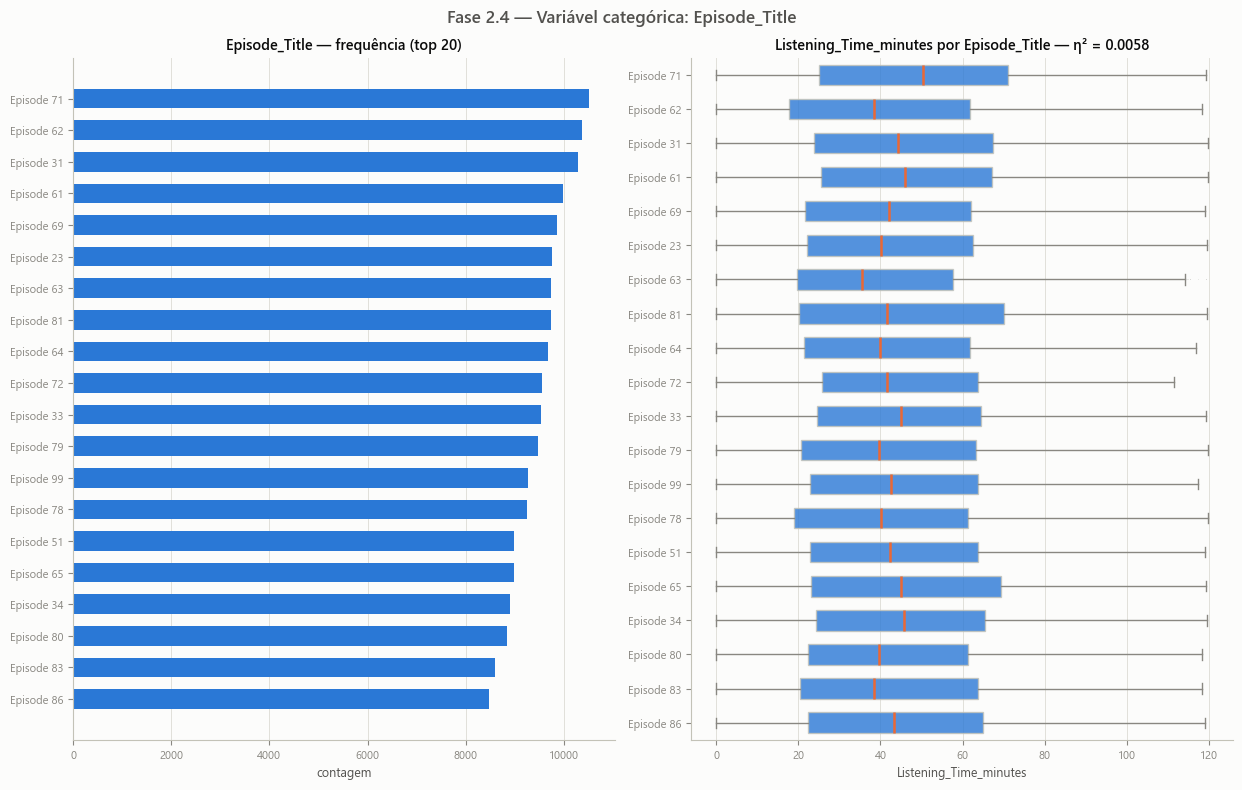

In [24]:
amostra_box = amostrar(train, cfg.amostra_boxplot, cfg.random_state)

for c in todas_cat:
    agrupado = detalhes_cat[c]
    top = agrupado.nlargest(cfg.top_n_categorias, "n").sort_values("n")
    niveis = top[c].tolist()
    altura = max(3.2, 0.32 * len(niveis) + 1.6)

    fig, (ax_freq, ax_alvo) = plt.subplots(1, 2, figsize=(12.5, altura))
    pos = np.arange(len(niveis))

    ax_freq.barh(pos, top["n"], color=SERIE_1, height=0.62)
    ax_freq.set_yticks(pos, [str(v) for v in niveis])
    ax_freq.set_xlabel("contagem")
    ax_freq.set_title(f"{c} — frequência (top {len(niveis)})")
    ax_freq.grid(axis="y", visible=False)

    grupos = [amostra_box.loc[amostra_box[c] == n, cfg.target].dropna().to_numpy()
              for n in niveis]
    cx = ax_alvo.boxplot(grupos, vert=False, widths=0.6, patch_artist=True,
                         flierprops={"marker": ".", "markersize": 1.5,
                                     "markerfacecolor": TINTA_SUAVE,
                                     "markeredgecolor": "none", "alpha": 0.2})
    for a in cx["boxes"]:
        a.set(facecolor=SERIE_1, edgecolor=EIXO, alpha=0.8)
    for el in ("whiskers", "caps"):
        for a in cx[el]:
            a.set(color=TINTA_SUAVE, linewidth=1.0)
    for a in cx["medians"]:
        a.set(color=SERIE_2, linewidth=1.8)
    ax_alvo.set_yticks(pos + 1, [str(v) for v in niveis])
    ax_alvo.set_xlabel(cfg.target)
    eta2 = float(resumo_cat.loc[resumo_cat["coluna"] == c, "eta2_vs_alvo"].iloc[0])
    ax_alvo.set_title(f"{cfg.target} por {c} — η² = {eta2:.4f}")
    ax_alvo.grid(axis="y", visible=False)

    fig.suptitle(f"Fase 2.4 — Variável categórica: {c}", fontsize=12.5,
                 fontweight="semibold", color=TINTA_SECUNDARIA)
    fig.tight_layout()
    plt.show()

**Leitura dos boxplots:** em todas as variáveis as caixas estão praticamente
alinhadas — as medianas mal se deslocam de uma categoria para outra. Visualmente
é a mesma conclusão do η².

Duas observações úteis para a Fase 3:

- **`Episode_Title` tem 100 categorias e `Podcast_Name` tem 48.** One-Hot Encoding
  nelas adicionaria 148 colunas para capturar menos de 1% de variância. *Target
  encoding* ou agrupamento são alternativas mais econômicas — se é que vale manter
  essas colunas.
- **`Episode_Title` é o texto "Episode N"**, com N de 1 a 100. É um número
  disfarçado de texto. Extrair o inteiro seria o caminho natural, mas isso já é
  engenharia de features (fora do escopo deste notebook) — fica registrado para a
  fase seguinte.
- Nenhuma categoria domina o dataset (a maior concentração é `Publication_Time =
  Night`, com 26%), então não há colunas quase constantes para descartar.

## 2.5 Matriz de correlação

Dois coeficientes lado a lado:

- **Pearson** mede relação **linear**
- **Spearman** mede relação **monotônica** (captura relações não lineares que
  preservem a ordem)

Quando os dois diferem muito, há relação não linear. Quando são parecidos, a
relação é essencialmente linear.

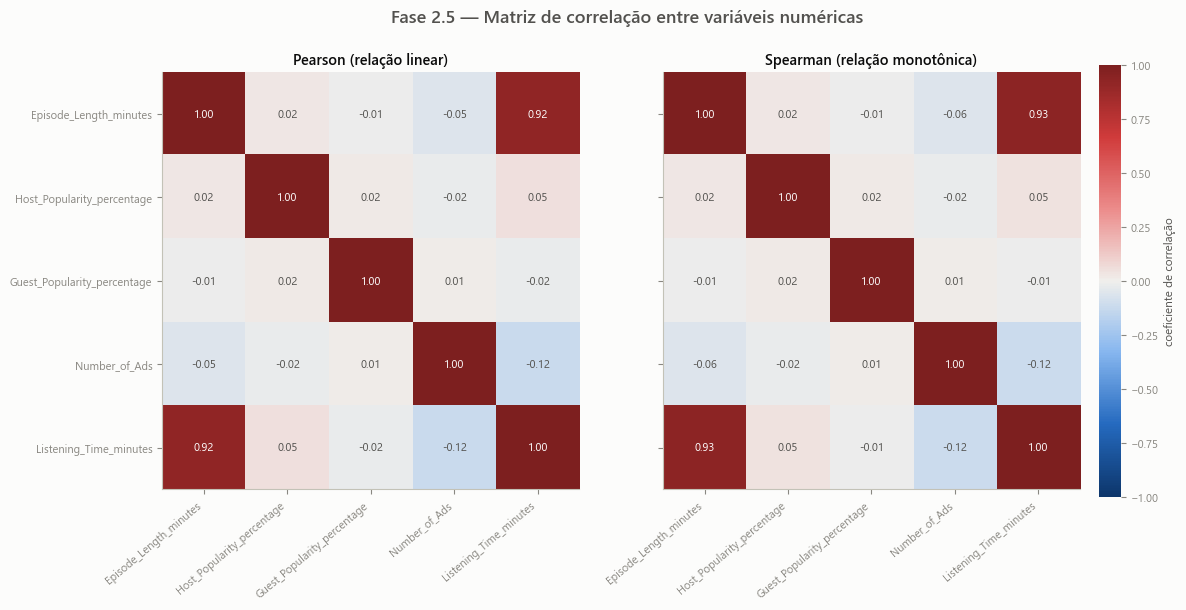

In [25]:
nums_corr = colunas.numericas + [cfg.target]
pearson = train[nums_corr].corr(method="pearson")
spearman = train[nums_corr].corr(method="spearman")

def desenhar_heatmap(ax, matriz, titulo, rotular_y):
    img = ax.imshow(matriz.to_numpy(), cmap=DIVERGENTE, vmin=-1, vmax=1)
    rotulos = list(matriz.columns)
    ax.set_xticks(range(len(rotulos)), rotulos, rotation=40, ha="right")
    ax.set_yticks(range(len(rotulos)), rotulos if rotular_y else [""] * len(rotulos))
    ax.set_title(titulo)
    ax.grid(visible=False)
    for i in range(len(rotulos)):
        for j in range(len(rotulos)):
            v = matriz.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="#ffffff" if abs(v) > 0.55 else TINTA_SECUNDARIA)
    return img

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.6))
desenhar_heatmap(ax1, pearson, "Pearson (relação linear)", True)
img = desenhar_heatmap(ax2, spearman, "Spearman (relação monotônica)", False)
barra = fig.colorbar(img, ax=[ax1, ax2], fraction=0.025, pad=0.02)
barra.set_label("coeficiente de correlação", color=TINTA_SECUNDARIA, fontsize=8.5)
barra.outline.set_visible(False)
fig.suptitle("Fase 2.5 — Matriz de correlação entre variáveis numéricas",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
plt.show()

In [26]:
# Pares REDUNDANTES entre preditoras (o alvo fica de fora: correlação alta com
# ele é sinal desejável, não motivo para descartar coluna).
preditoras = [c for c in pearson.columns if c != cfg.target]
pares = [
    {"variavel_a": a, "variavel_b": b, "pearson": round(float(pearson.loc[a, b]), 4)}
    for i, a in enumerate(preditoras)
    for b in preditoras[i + 1:]
    if abs(pearson.loc[a, b]) >= cfg.limite_correlacao_alta
]
redundantes = pd.DataFrame(pares)

print(f"Pares de preditoras com |r| >= {cfg.limite_correlacao_alta}: {len(redundantes)}")
redundantes if not redundantes.empty else "Nenhum par redundante entre preditoras."

Pares de preditoras com |r| >= 0.9: 0


'Nenhum par redundante entre preditoras.'

**Leitura:**

- **As preditoras são mutuamente independentes.** Todas as correlações entre elas
  ficam abaixo de |0,06|. Não há multicolinearidade, então a etapa de seleção por
  VIF / correlação > 0,9 prevista na Fase 3 **não vai eliminar nada**.
- A única correlação forte da matriz é `Episode_Length_minutes` × alvo (0,92), e
  essa é a que **queremos** manter.
- Pearson e Spearman quase idênticos em toda a matriz → as relações são lineares;
  não há sinal escondido que a correlação linear esteja perdendo.

Atenção a uma armadilha comum: a correlação de 0,92 aparece na matriz junto com as
outras, mas ela envolve o **alvo**. Um filtro automático de "remova uma variável de
todo par com |r| > 0,9" descartaria justamente a variável mais preditiva do
dataset. Por isso o alvo é excluído da busca por pares redundantes na célula acima.

## 2.6 Regras lógicas de domínio

As seções anteriores mostraram que a estatística descritiva **não** encontra os
erros deste dataset. O que encontra são regras que descrevem o que é impossível
no mundo real.

Aqui verificamos três condições que **não deveriam existir**:

1. `Listening_Time_minutes > Episode_Length_minutes` — escutar mais do que o episódio dura
2. `Number_of_Ads > 10` — a escala real da variável é 0 a 3
3. `Episode_Length_minutes <= 0` — episódio de duração nula ou negativa

Somamos a isso uma checagem semântica automática: colunas cujo nome indica
percentual não podem ter valores fora de [0; 100].

In [27]:
linhas_regras = []
for regra in cfg.regras_logicas:
    violacoes = len(train.query(regra))
    linhas_regras.append({
        "regra_violada": regra,
        "linhas": violacoes,
        "pct_do_dataset": round(100 * violacoes / len(train), 4),
    })

# Checagem semântica: colunas de percentual fora de [0, 100].
for c in colunas.numericas:
    if any(t in c.lower() for t in ("percentage", "percent", "_pct", "pct_")):
        fora = int(((train[c] < 0) | (train[c] > 100)).sum())
        if fora:
            linhas_regras.append({
                "regra_violada": f"{c} fora de [0, 100]  (máx {train[c].max():.2f})",
                "linhas": fora,
                "pct_do_dataset": round(100 * fora / len(train), 4),
            })

pd.DataFrame(linhas_regras).sort_values("linhas", ascending=False)

,regra_violada,linhas,pct_do_dataset
0,Listening_Time_minutes > Episode_Length_minutes,2568,0.3424
3,"Host_Popularity_percentage fora de [0, 100] (...",25,0.0033
4,"Guest_Popularity_percentage fora de [0, 100] ...",19,0.0025
1,Number_of_Ads > 10,9,0.0012
2,Episode_Length_minutes <= 0,1,0.0001


### Investigando as linhas impossíveis

2.568 linhas violam a regra principal. Antes de decidir o que fazer com elas, vale
perguntar **de quanto** é a violação — a resposta muda completamente o tratamento.

In [28]:
impossiveis = train.query("Listening_Time_minutes > Episode_Length_minutes").copy()
impossiveis["excesso"] = impossiveis[cfg.target] - impossiveis["Episode_Length_minutes"]

print(f"Linhas impossíveis: {len(impossiveis):,}".replace(",", "."))
print(f"Excesso médio:   {impossiveis['excesso'].mean():.2f} min")
print(f"Excesso mediano: {impossiveis['excesso'].median():.4f} min")
print(f"Excesso máximo:  {impossiveis['excesso'].max():.2f} min")

pd.DataFrame([
    {
        "faixa": f"excesso <= {lim} min",
        "linhas": int((impossiveis["excesso"] <= lim).sum()),
        "pct_das_impossiveis": round(100 * (impossiveis["excesso"] <= lim).mean(), 1),
    }
    for lim in (0.01, 0.1, 1, 5, 10)
])

Linhas impossíveis: 2.568
Excesso médio:   1.67 min
Excesso mediano: 0.0202 min
Excesso máximo:  115.54 min


,faixa,linhas,pct_das_impossiveis
0,excesso <= 0.01 min,1142,44.5000
1,excesso <= 0.1 min,1703,66.3000
2,excesso <= 1 min,2185,85.1000
3,excesso <= 5 min,2483,96.7000
4,excesso <= 10 min,2506,97.6000


In [29]:
# Grupo 1 — excesso desprezível: o ouvinte escutou o episódio INTEIRO e a
# diferença é ruído de arredondamento na casa decimal.
print("Grupo 1 — arredondamento (excesso <= 1 min):")
display(impossiveis.nsmallest(5, "excesso")[
    ["id", "Episode_Length_minutes", cfg.target, "excesso"]
])

# Grupo 2 — erro real: o alvo não tem relação com a duração registrada.
grandes = impossiveis[impossiveis["excesso"] > 5]
print(f"\nGrupo 2 — erro real (excesso > 5 min): {len(grandes)} linhas")
grandes.nlargest(5, "excesso")[["id", "Episode_Length_minutes", cfg.target, "excesso"]]

Grupo 1 — arredondamento (excesso <= 1 min):


,id,Episode_Length_minutes,Listening_Time_minutes,excesso
81794,81794,7.4647,7.4648,0.0000
176138,176138,7.4647,7.4648,0.0000
596573,596573,7.4647,7.4648,0.0000
603378,603378,7.4647,7.4648,0.0000
646109,646109,7.4647,7.4648,0.0000



Grupo 2 — erro real (excesso > 5 min): 85 linhas


,id,Episode_Length_minutes,Listening_Time_minutes,excesso
250219,250219,1.2400,116.7800,115.5400
453791,453791,1.4800,116.7700,115.2900
63965,63965,12.0100,113.3318,101.3218
3859,3859,12.0900,113.3318,101.2418
583239,583239,12.6700,111.3400,98.6700


**Leitura — e aqui a regra bruta engana:**

| faixa de excesso | linhas | % das impossíveis |
|---|---|---|
| ≤ 0,01 min (menos de 1 segundo) | 1.142 | 44,5% |
| ≤ 1 min | 2.185 | 85,1% |
| ≤ 5 min | 2.483 | 96,7% |
| **> 5 min (erro real)** | **85** | **3,3%** |

São **duas populações distintas** dentro da mesma violação:

- **~2.483 linhas (96,7%) são arredondamento.** O excesso mediano é de 0,02 minutos
  — cerca de um segundo. Estes são ouvintes que escutaram o episódio **inteiro**, e a
  diferença vem da precisão decimal das duas colunas. Não são erro: são o sinal
  "escuta completa", que provavelmente é informativo.
- **85 linhas (3,3%) são erro genuíno.** Casos como `id 3859`: episódio de 12,09
  minutos com 113,33 minutos de escuta registrados. Aqui o alvo não tem relação
  nenhuma com a duração.

**Por que isso importa:** aplicar a regra literalmente e descartar as 2.568 linhas
jogaria fora 2.483 observações perfeitamente válidas — e justamente as do
comportamento "escutou tudo", que fica no topo da faixa do alvo. A regra correta
para a Fase 3 usa uma tolerância:

```python
# em vez de:  Listening_Time_minutes > Episode_Length_minutes
# use:        Listening_Time_minutes > Episode_Length_minutes + tolerância
```

**Comparação com a seção 2.3:**

| método | erros reais encontrados |
|---|---|
| regra IQR (o que o diagrama prevê para a Fase 3) | 10 linhas |
| regras de domínio (com tolerância) | ~130 linhas |

As regras de domínio ainda encontram uma ordem de grandeza mais problemas que o
IQR. Mas o exercício mostra os dois lados da lição: **estatística descritiva sozinha
não acha os erros, e regra de domínio aplicada sem olhar a magnitude cria erros
novos.**

Sobre a origem: as linhas impossíveis têm duração média de 49,1 minutos contra
64,5 da base completa, ou seja, concentram-se em episódios mais curtos. Somando
isso aos 11,6% de ausentes na mesma coluna, a hipótese mais provável é que o
dataset foi gerado sinteticamente e o ruído injetado em `Episode_Length_minutes`
quebrou a relação com o alvo em uma fração das linhas.

## 2.7 Alertas consolidados

Tudo o que a EDA encontrou, reunido numa lista priorizada. Esta tabela é a
**entrada da Fase 3**: cada linha é uma decisão a tomar.

In [30]:
alertas = consolidar_alertas(
    train, cfg, colunas, descricao, resumo_num, corr_alvo, resumo_cat, redundantes
)

print(alertas["severidade"].value_counts().to_string())
alertas

severidade
info       6
critico    5
atencao    5


,severidade,coluna,achado,acao_sugerida
0,critico,Episode_Length_minutes <= 0,1 linhas violam a regra (0.000%),inconsistencia logica - investigar antes de mo...
1,critico,Guest_Popularity_percentage,"valores fora de [0, 100] (min 0.00, max 119.91)",valores impossiveis para um percentual - corri...
2,critico,Host_Popularity_percentage,"valores fora de [0, 100] (min 1.30, max 119.46)",valores impossiveis para um percentual - corri...
3,critico,Listening_Time_minutes > Episode_Length_minutes,2568 linhas violam a regra (0.342%),inconsistencia logica - investigar antes de mo...
4,critico,Number_of_Ads > 10,9 linhas violam a regra (0.001%),inconsistencia logica - investigar antes de mo...
5,atencao,Episode_Length_minutes,87093 ausentes (11.612%),imputar (mediana/moda/KNN) e criar flag de aus...
6,atencao,Episode_Title,100 categorias,OHE explode a dimensionalidade - usar target/o...
7,atencao,Guest_Popularity_percentage,146030 ausentes (19.471%),imputar (mediana/moda/KNN) e criar flag de aus...
8,atencao,Number_of_Ads,1 ausentes (0.000%),imputar (mediana/moda/KNN) e criar flag de aus...
9,atencao,Number_of_Ads,assimetria de 6.03,"avaliar transformacao (log1p, Box-Cox) para mo..."


---
# Conclusões e próximos passos

## O que os dados dizem

**1. O problema é quase unidimensional.** `Episode_Length_minutes` tem Pearson
0,917 com o alvo — sozinha explica ~84% da variância. Todas as outras variáveis
somadas contribuem pouco: a segunda numérica mais forte é `Number_of_Ads` (−0,118)
e a melhor categórica explica 0,58% da variância.

**2. As variáveis categóricas são quase irrelevantes.** Todos os η² abaixo de
0,006. `Genre`, `Publication_Day` e `Publication_Time` estão abaixo de 0,0007.
Investir em encoding sofisticado para elas tem retorno baixo.

**3. Não há multicolinearidade.** Todas as correlações entre preditoras abaixo de
|0,06|. A etapa de seleção por VIF prevista na Fase 3 não vai eliminar nada.

**4. Os dados têm erros que a estatística descritiva não pega.** A regra IQR encontra
10 linhas problemáticas; as regras de domínio encontram ~130 erros reais. Mas atenção:
a regra bruta "escuta > duração" marca 2.568 linhas, das quais **96,7% são apenas
arredondamento** (escuta completa do episódio). Sem olhar a magnitude da violação,
o tratamento descartaria 2.483 linhas válidas.

**5. O `test` é mais sujo que o `train`** e precisa do mesmo tratamento —
inclusive valores absurdos que só existem nele.

## O que fazer na Fase 3 (pré-processamento)

| Prioridade | Ação | Por quê |
|---|---|---|
| **Alta** | Tratar as violações de domínio **com tolerância** | 85 linhas têm o alvo genuinamente impossível; as outras 2.483 são escuta completa com arredondamento e devem ser preservadas |
| **Alta** | Corrigir percentuais > 100 e `Number_of_Ads` > 3 | Valores impossíveis, invisíveis para o IQR |
| **Alta** | Aplicar o mesmo tratamento ao `test` | Ele tem extremos que o `train` não tem (78 milhões de minutos) |
| **Alta** | Imputar `Episode_Length_minutes` (11,6% ausentes) com cuidado | É a variável mais preditiva; imputar pela mediana degrada o sinal principal — testar KNN ou regressão |
| **Média** | Imputar `Guest_Popularity_percentage` (19,5% ausentes) + flag de ausência | Sinal fraco, mas a *ausência* em si pode ser informativa (episódio sem convidado) |
| **Média** | Investigar os 1,14% de alvo = 0 | Comportamento qualitativamente diferente do resto |
| **Baixa** | Encoding das categóricas | η² baixíssimo; OHE em `Episode_Title` + `Podcast_Name` custaria 148 colunas |
| **Dispensável** | Seleção por VIF / correlação > 0,9 | Não há multicolinearidade a eliminar |
| **Dispensável** | Clipping por IQR | Encontra 10 linhas; as regras de domínio já resolveram o problema |

## Ajustes sugeridos ao plano original

Três pontos do diagrama que a evidência recomenda revisar:

1. **A Fase 3 prevê tratamento de outliers por IQR/z-score.** Demonstramos que
   isso é quase inócuo aqui. Substituir por validação de regras de domínio — mas
   sempre inspecionando a **magnitude** da violação antes de decidir o tratamento,
   como fizemos na seção 2.6.
2. **A Fase 4 prevê "K-Fold estratificado".** Estratificação é para classificação;
   com alvo contínuo, use `KFold` simples ou estratifique por faixas do alvo
   (`pd.qcut`).
3. **A Fase 4 prevê RMSLE entre as métricas.** O alvo não tem cauda longa nem
   cobre várias ordens de grandeza — RMSE e MAE bastam.

## Sobre a Fase 4

Como o sinal linear é forte e as preditoras são independentes, a regressão linear
deve chegar perto do teto do que é linearmente extraível. O ganho dos modelos de
árvore virá de duas coisas: a **restrição de teto** (o alvo nunca excede a duração
do episódio) e o efeito **não linear** dos anúncios sobre a fração escutada. Vale
medir o baseline linear primeiro para ter contra o que comparar.

---

### Reprodutibilidade

Este notebook é a versão narrada da análise. A versão automatizada roda em um
comando e escreve relatório, figuras e tabelas em disco:

```bash
python Pipeline/run_eda.py
```

E funciona sobre qualquer outro dataset, bastando trocar os parâmetros:

```bash
python Pipeline/run_eda.py --train dados/treino.csv --target preco --sem-test
```